<a href="https://colab.research.google.com/github/andrea21gonzarza/diabetes-classification-ml/blob/main/diabetes_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clasificación de pacientes con diabetes usando aprendizaje automático

El objetivo de este proyecto es desarrollar y evaluar diferentes modelos de aprendizaje automático para clasificar el resultado de diabetes registrado en el conjunto de datos Pima Indians Diabetes Database basado en variables clínicas y antropométricas.

## 1. Carga e inspección inicial de los datos

In [1]:
# Importación de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Carga del conjunto de datos
df = pd.read_csv('diabetes.csv')

In [3]:
# Visualización de las primeras 5 observaciones
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
# Dimensiones del conjunto de datos
df.shape

(768, 9)

In [5]:
# Información general del conjunto de datos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
# Estadísticos descriptivos
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## 2. Evaluación de la calidad de los datos

En este apartado se lleva a cabo una evaluación de la calidad del conjunto de datos original mediante la detección de valores faltantes, registros duplicados y valores que podrían no ser válidos. Asimismo, se examina la distribución de la variable objetivo antes de emprender cualquier procedimiento de preprocesamiento.

In [7]:
# Comprobación de valores nulos
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [8]:
# Comprobación de registros duplicados
df.duplicated().sum()

np.int64(0)

In [9]:
# Variables en las que un valor de cero puede representar un dato faltante
variables_cero = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

# Número de valores iguales a cero por variable
(df[variables_cero] == 0).sum()

,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11


In [10]:
# Porcentaje de valores iguales a cero por variable
porcentaje_ceros = (df[variables_cero] == 0).mean() * 100
porcentaje_ceros.round(2)

,0
Glucose,0.65
BloodPressure,4.56
SkinThickness,29.56
Insulin,48.70
BMI,1.43


In [11]:
# Distribución de la variable objetivo
df["Outcome"].value_counts()

,count
Outcome,
0,500
1,268


In [12]:
# Distribución porcentual de la variable objetivo
(df["Outcome"].value_counts(normalize=True) * 100).round(2)

,proportion
Outcome,
0,65.1
1,34.9


In [13]:
# Resumen de valores iguales a cero
resumen_ceros = pd.DataFrame({"Número de ceros": (df[variables_cero] == 0).sum(),
                              "Porcentaje (%)": ((df[variables_cero] == 0).mean() * 100).round(2)})

resumen_ceros

,Número de ceros,Porcentaje (%)
Glucose,5,0.65
BloodPressure,35,4.56
SkinThickness,227,29.56
Insulin,374,48.70
BMI,11,1.43


In [14]:
# Crear una copia del conjunto de datos original
df_clean = df.copy()

In [15]:
# Sustituir los ceros no admisibles clínicamente por valores ausentes
df_clean[variables_cero] = df_clean[variables_cero].replace(0, np.nan)

In [16]:
# Comprobar los valores ausentes después de sustituir los ceros
df_clean[variables_cero].isnull().sum()

,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11


## 3. Preparación y divisón de los datos

En este apartado se distinguen las variables predictoras respecto de la variable objetivo y se fracciona el conjunto de datos en subconjuntos de entrenamiento y prueba. Esta partición se efectúa antes de ajustar los procedimientos de imputación y de escalado, con el fin de prevenir la aparición de data leakage entre los datos de entrenamiento y prueba.

In [17]:
# Separación de variables predictoras y variable objetivo
X = df_clean.drop("Outcome", axis=1)
y = df_clean["Outcome"]

In [18]:
from sklearn.model_selection import train_test_split

In [19]:
# División en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

In [20]:
# Tamaño de los conjuntos de entrenamiento y prueba
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (614, 8)
X_test: (154, 8)
y_train: (614,)
y_test: (154,)


In [21]:
# Distribución de clases en el conjunto de entrenamiento
print("Entrenamiento:")
print((y_train.value_counts(normalize=True) * 100).round(2))

# Distribución de clases en el conjunto de prueba
print("\nPrueba:")
print((y_test.value_counts(normalize=True) * 100).round(2))

Entrenamiento:
Outcome
0    65.15
1    34.85
Name: proportion, dtype: float64

Prueba:
Outcome
0    64.94
1    35.06
Name: proportion, dtype: float64


### 3.1 Imputación de valores faltantes

Los valores faltantes detectados en las variables clínicas se completarán mediante la mediana. La imputación se calibrará empleando únicamente el conjunto de entrenamiento, de modo que la información del conjunto de prueba no participe en el preprocesamiento de los datos.

In [22]:
# Importar el método de imputación
from sklearn.impute import SimpleImputer

# Crear el imputador utilizando la mediana
imputador = SimpleImputer(strategy="median")

In [23]:
# Ajustar el imputador únicamente con el conjunto de entrenamiento
imputador.fit(X_train)

SimpleImputer(strategy='median')

In [24]:
# Visualizar las medianas calculadas a partir del conjunto de entrenamiento
medianas = pd.Series(imputador.statistics_, index=X_train.columns)

medianas

,0
Pregnancies,3.0000
Glucose,117.0000
BloodPressure,72.0000
SkinThickness,29.0000
Insulin,125.0000
BMI,32.4000
DiabetesPedigreeFunction,0.3825
Age,29.0000


In [25]:
# Aplicar la imputación a entrenamiento y prueba
X_train_imputed = pd.DataFrame(imputador.transform(X_train), columns=X_train.columns,
                               index=X_train.index)

X_test_imputed = pd.DataFrame(imputador.transform(X_test), columns=X_test.columns,
                              index=X_test.index)

In [26]:
# Comprobar que no quedan valores faltantes
print("Valores faltantes en entrenamiento:")
print(X_train_imputed.isnull().sum())

print("\nValores faltantes en prueba:")
print(X_test_imputed.isnull().sum())

Valores faltantes en entrenamiento:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64

Valores faltantes en prueba:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64


### 3.2 Estandarización de las variables

Las variables predictoras muestran distintas escalas de medición. Por ello, se realizará una estandarización en los algoritmos sensibles a la escala, como la regresión logística. En los modelos fundamentados en árboles, como el árbol de decisión y Random Forest, este procedimiento no es estrictamente necesario, dado que sus decisiones se sustentan en puntos de corte definidos sobre las variables.

El escalador se ajustará solo con los datos del conjunto de entrenamiento y, posteriormente, se aplicará al conjunto de prueba; de este modo, ese evita incorporar información proveniente del conjunto de prueba durante el entrenamiento.

In [27]:
# Importar el método de estandarización
from sklearn.preprocessing import StandardScaler

# Crear el escalador
scaler = StandardScaler()

In [28]:
# Ajustar el escalador y transformar el conjunto de entrenamiento
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_imputed), columns=X_train_imputed.columns,
                              index=X_train_imputed.index)

In [29]:
# Transformar el conjunto de prueba utilizando el escalador ajustado con los datos de entrenamiento
X_test_scaled = pd.DataFrame(scaler.transform(X_test_imputed), columns=X_test_imputed.columns,
                             index=X_test_imputed.index)

In [30]:
# Comprobar la media y desviación estándar
print("Media de las variables estandarizadas:")
print(X_train_scaled.mean().round(2))

print("\nDesviación estándar:")
print(X_train_scaled.std().round(2))

Media de las variables estandarizadas:
Pregnancies                -0.0
Glucose                    -0.0
BloodPressure               0.0
SkinThickness              -0.0
Insulin                    -0.0
BMI                         0.0
DiabetesPedigreeFunction   -0.0
Age                        -0.0
dtype: float64

Desviación estándar:
Pregnancies                 1.0
Glucose                     1.0
BloodPressure               1.0
SkinThickness               1.0
Insulin                     1.0
BMI                         1.0
DiabetesPedigreeFunction    1.0
Age                         1.0
dtype: float64


## 4. Análisis Exploratorio de Datos (EDA)

Este apartado está orientado a realizar un análisis exploratorio de las variables predictoras, con el fin de examinar su distribución, detectar posibles valores atípicos y estudiar su relación con la variable objetivo Outcome.

### 4.1 Distribución de las variables predictoras

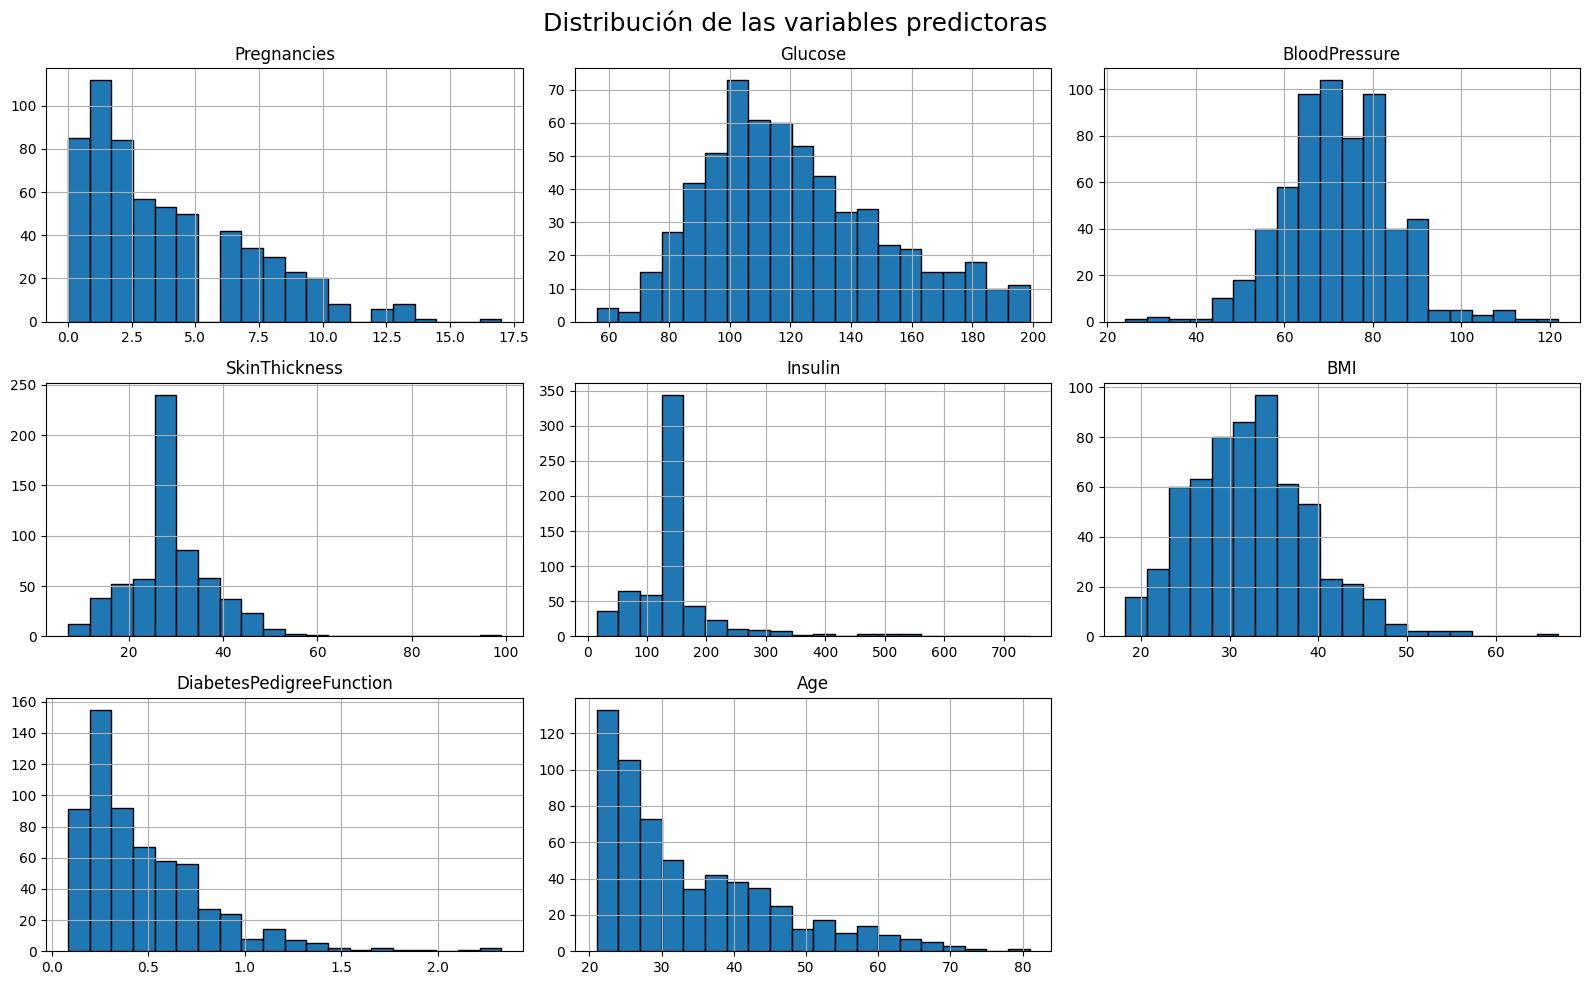

In [31]:
# Histogramas de las variables predictoras
X_train_imputed.hist(figsize=(16, 10), bins=20, edgecolor="black")

plt.suptitle("Distribución de las variables predictoras", fontsize=18)
plt.tight_layout()
plt.show()

### 4.1 Identificación de posibles valores extremos

En este apartado se examina la posible existencia de valores atípicos en las variables predictoras mediante diagramas de caja. Dichos valores no se eliminan de manera automática, dado que podrían reflejar observaciones clínicas válidas.

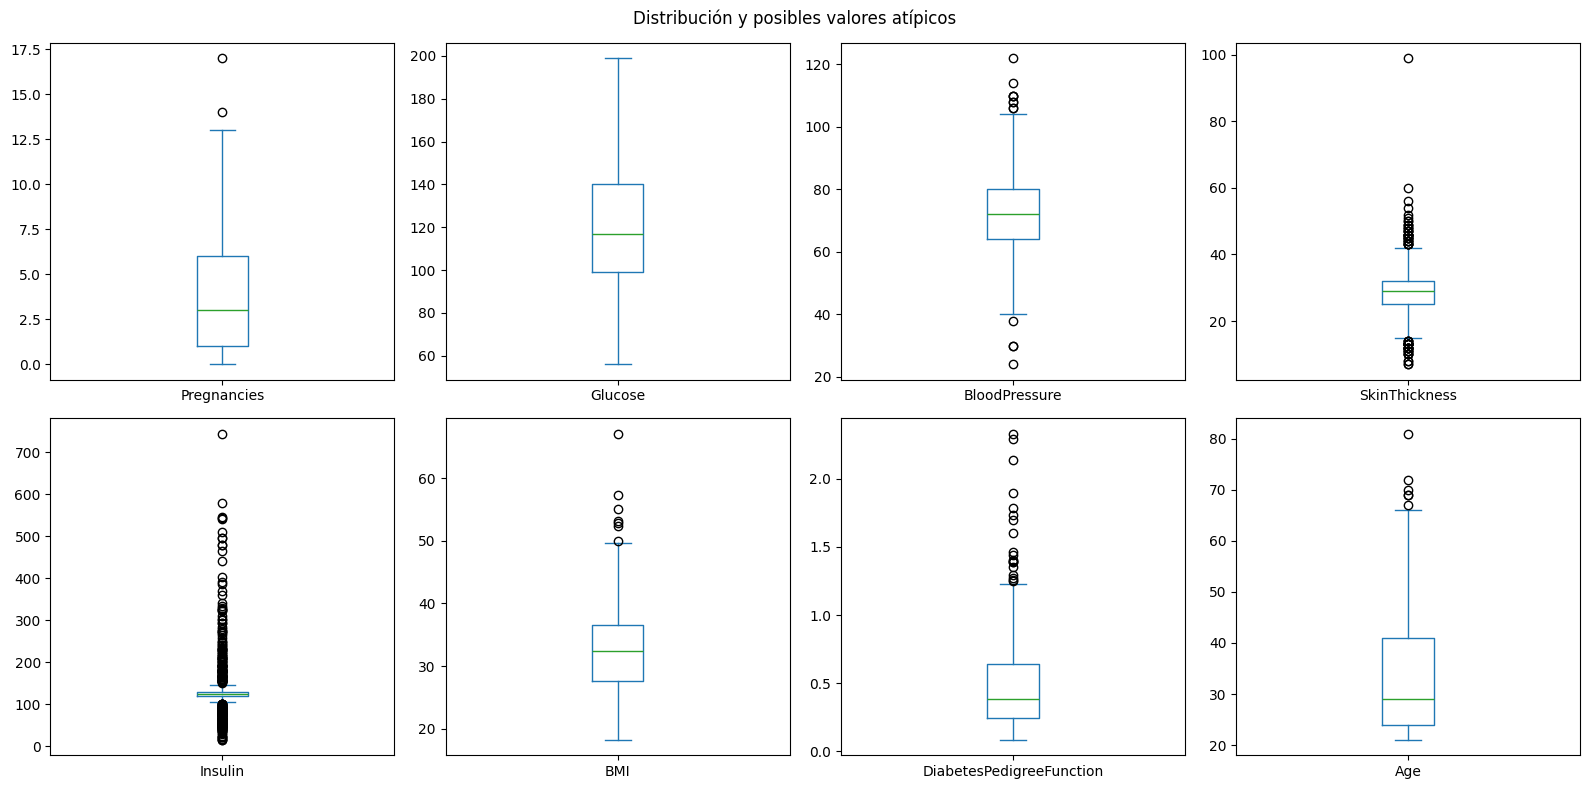

In [32]:
# Diagramas de caja de las variables predictoras
X_train_imputed.plot(kind="box", subplots=True, layout=(2, 4), figsize=(16, 8))

plt.suptitle("Distribución y posibles valores atípicos")
plt.tight_layout()
plt.show()

### 4.3 Distribución de las variables según Outcome

Se analizó la distribución de las variables predictoras entre las categorías de la variable objetivo, con el fin de investigar posibles diferencias entre los pacientes con Outcome = 0 y Outcome = 1.

In [33]:
# Crear conjunto de entrenamiento para el análisis exploratorio
train_eda = X_train_imputed.copy()
train_eda["Outcome"] = y_train

In [34]:
train_eda.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
353,1.0,90.0,62.0,12.0,43.0,27.2,0.580,24.0,0
711,5.0,126.0,78.0,27.0,22.0,29.6,0.439,40.0,0
373,2.0,105.0,58.0,40.0,94.0,34.9,0.225,25.0,0
46,1.0,146.0,56.0,29.0,125.0,29.7,0.564,29.0,0
682,0.0,95.0,64.0,39.0,105.0,44.6,0.366,22.0,0


In [35]:
# Estadísticos descriptivos de las variables predictoras
estadisticos_eda = train_eda.drop(columns="Outcome").describe().T

# Añadir la mediana
estadisticos_eda["Mediana"] = (train_eda.drop(columns="Outcome").median())

# Seleccionar los estadísticos de interés
estadisticos_eda = estadisticos_eda[["mean", "std", "Mediana", "min", "max"]]

# Renombrar las columnas
estadisticos_eda.columns = ["Media", "Desviación estándar", "Mediana", "Mínimo",
                            "Máximo"]

# Mostrar resultados
estadisticos_eda.round(2)

,Media,Desviación estándar,Mediana,Mínimo,Máximo
Pregnancies,3.82,3.31,3.00,0.00,17.00
Glucose,121.67,30.00,117.00,56.00,199.00
BloodPressure,72.14,12.28,72.00,24.00,122.00
SkinThickness,29.04,8.89,29.00,7.00,99.00
Insulin,137.71,78.76,125.00,15.00,744.00
BMI,32.45,6.82,32.40,18.20,67.10
DiabetesPedigreeFunction,0.48,0.33,0.38,0.08,2.33
Age,33.37,11.83,29.00,21.00,81.00


In [36]:
# Mediana de las variables predictoras según Outcome
train_eda.groupby("Outcome").median().round(2)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,2.0,108.0,70.0,29.0,125.0,30.45,0.34,27.0
1,4.0,141.0,74.0,29.0,125.0,34.30,0.46,36.0


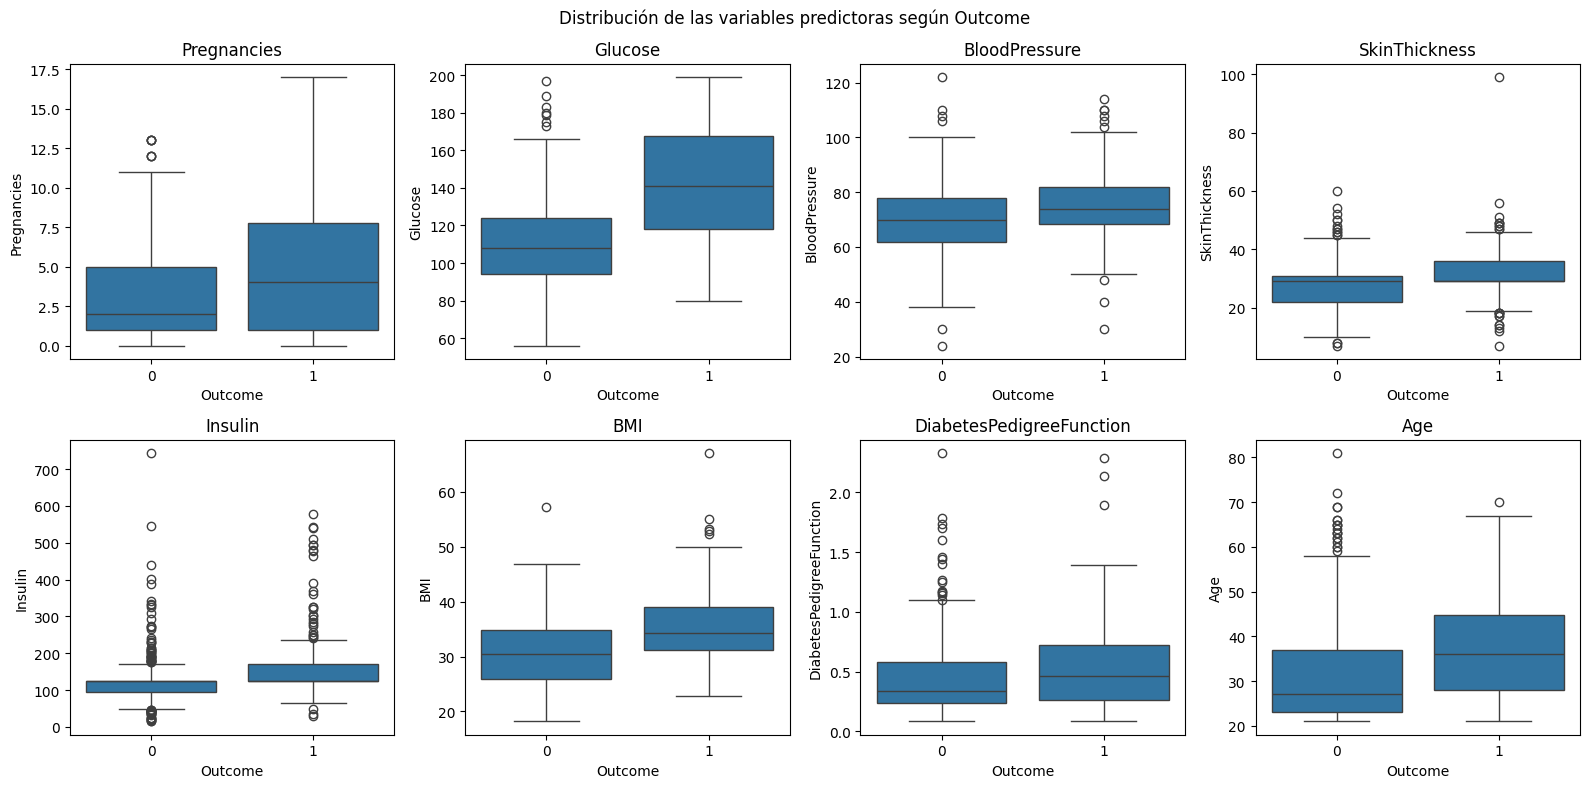

In [37]:
# Comparación de las variables predictoras según Outcome

variables = X_train_imputed.columns

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, variable in enumerate(variables):
    sns.boxplot(data=train_eda, x="Outcome", y=variable, ax=axes[i])
    axes[i].set_title(variable)

plt.suptitle("Distribución de las variables predictoras según Outcome")
plt.tight_layout()
plt.show()

### 4.4 Análisis de correlación

En esta sección se examina la correlación entre las variables del conjunto de entrenamiento, con el fin de detectar posibles relaciones lineales entre los predictores y, además, evaluar cómo se vinculan con la variable objetivo.

In [38]:
# Calcular la matriz de correlación
correlation_matrix = train_eda.corr()

correlation_matrix.round(2)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.00,0.14,0.20,0.09,0.06,0.01,-0.05,0.54,0.21
Glucose,0.14,1.00,0.22,0.22,0.45,0.23,0.14,0.29,0.51
BloodPressure,0.20,0.22,1.00,0.18,0.08,0.27,-0.00,0.32,0.18
SkinThickness,0.09,0.22,0.18,1.00,0.22,0.54,0.11,0.14,0.23
Insulin,0.06,0.45,0.08,0.22,1.00,0.21,0.19,0.12,0.25
BMI,0.01,0.23,0.27,0.54,0.21,1.00,0.16,0.03,0.33
DiabetesPedigreeFunction,-0.05,0.14,-0.00,0.11,0.19,0.16,1.00,0.03,0.17
Age,0.54,0.29,0.32,0.14,0.12,0.03,0.03,1.00,0.24
Outcome,0.21,0.51,0.18,0.23,0.25,0.33,0.17,0.24,1.00


In [39]:
# Correlación de las variables predictoras con Outcome
correlation_outcome = (correlation_matrix["Outcome"].drop("Outcome").sort_values(ascending=False))

correlation_outcome.round(2)

,Outcome
Glucose,0.51
BMI,0.33
Insulin,0.25
Age,0.24
SkinThickness,0.23
Pregnancies,0.21
BloodPressure,0.18
DiabetesPedigreeFunction,0.17


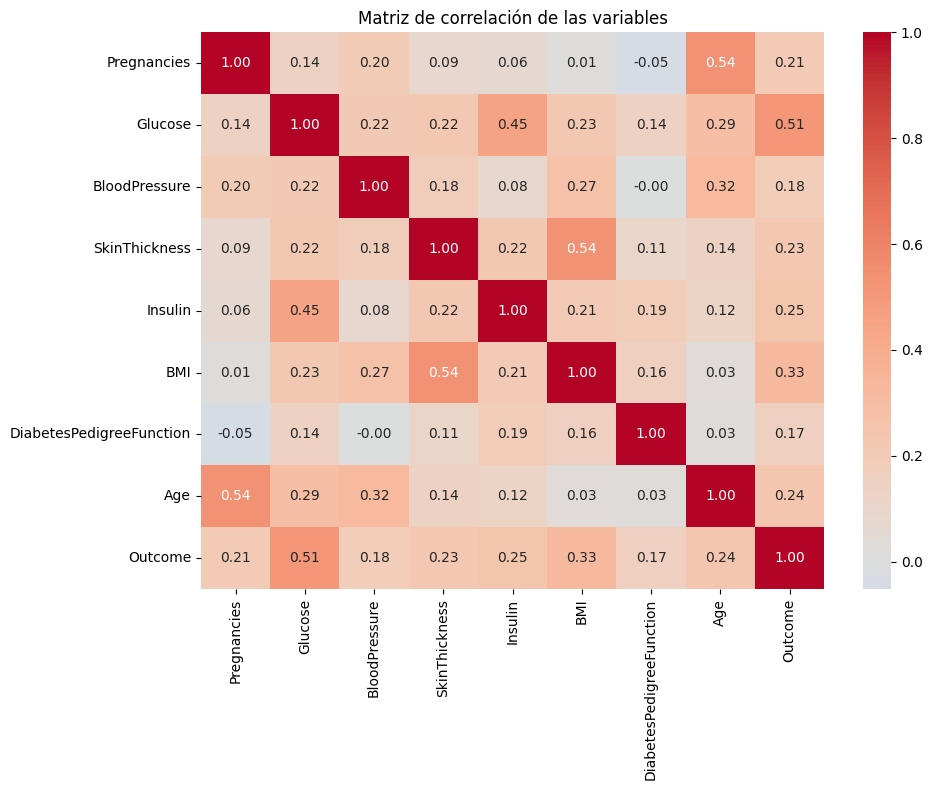

In [40]:
# Mapa de calor de la matriz de correlación
plt.figure(figsize=(10, 8))

sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            center=0)

plt.title("Matriz de correlación de las variables")
plt.tight_layout()
plt.show()

## 5. Desarrollo y evaluación de modelos de clasificación

En esta sección se formarán distintos algoritmos de aprendizaje automático con el fin de clasificar los resultados de diabetes. Los modelos se entrenarán empleando el conjunto de entrenamiento previamente preprocesado y, posteriormente, se evaluarán con el conjunto de prueba.

### 5.1 Regresión logística

La regresión logística se emplea como modelo inicial de clasificación. Dado que el algoritmo puede verse influido por las discrepancias de escala entre las variables predictoras, para su entrenamiento se usarán los datos previamente estandarizados.

In [41]:
# Importar el modelo de regresión logística
from sklearn.linear_model import LogisticRegression

# Crear el modelo
logistic_model = LogisticRegression(random_state=42, max_iter=1000)

# Entrenar el modelo
logistic_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [42]:
# Realizar predicciones sobre el conjunto de prueba
y_pred_logistic = logistic_model.predict(X_test_scaled)

# Visualizar las primeras predicciones
y_pred_logistic[:10]

array([1, 0, 0, 0, 0, 0, 0, 1, 0, 1])

### 5.1.1 Evaluación del modelo

El desempeño de la regresión logística se determina al contrastar las predicciones obtenidas para el conjunto de prueba con los valores observados reales. Con ese fin, se emplean diversas métricas de validación para evaluar el comportamiento del modelo.

In [43]:
# Importar métricas de evaluación
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_auc_score)

# Calcular las probabilidades de ser asignado a la clase positiva
y_prob_logistic = logistic_model.predict_proba(X_test_scaled)[:, 1]

# Calcular las métricas
accuracy = accuracy_score(y_test, y_pred_logistic)
precision = precision_score(y_test, y_pred_logistic)
sensitivity = recall_score(y_test, y_pred_logistic)
f1 = f1_score(y_test, y_pred_logistic)
roc_auc = roc_auc_score(y_test, y_prob_logistic)

# Obtener la matriz de confusión
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_logistic).ravel()

# Calcular especificidad
specificity = tn / (tn + fp)

# Mostrar resultados
print(f"Accuracy: {accuracy:.3f}")
print(f"Precisión: {precision:.3f}")
print(f"Sensibilidad (Recall): {sensitivity:.3f}")
print(f"Especificidad: {specificity:.3f}")
print(f"F1-score: {f1:.3f}")
print(f"ROC-AUC: {roc_auc:.3f}")

Accuracy: 0.708
Precisión: 0.600
Sensibilidad (Recall): 0.500
Especificidad: 0.820
F1-score: 0.545
ROC-AUC: 0.813


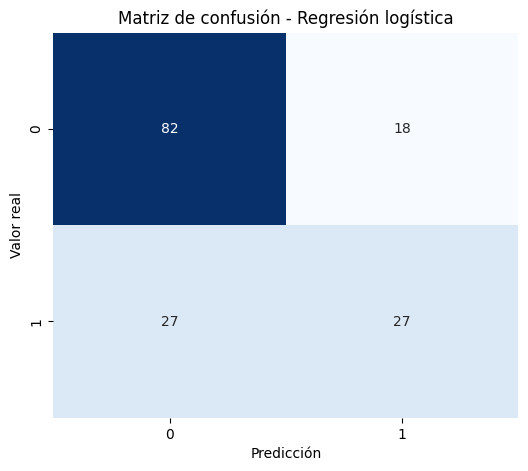

In [44]:
# Calcular la matriz de confusión
cm_logistic = confusion_matrix(y_test, y_pred_logistic)

# Visualizar la matriz de confusión
plt.figure(figsize=(6, 5))

sns.heatmap(cm_logistic, annot=True, fmt="d", cmap="Blues",
            cbar=False)

plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title("Matriz de confusión - Regresión logística")
plt.show()

### 5.1.2 Curva ROC

La curva ROC permite analizar el poder de discriminación del modelo en distintos umbrales de clasificación, a través de la relación entre la sensibilidad y la tasa de falsos positivos. El área bajo la curva (ROC-AUC) sintetiza dicha capacidad de discriminación.

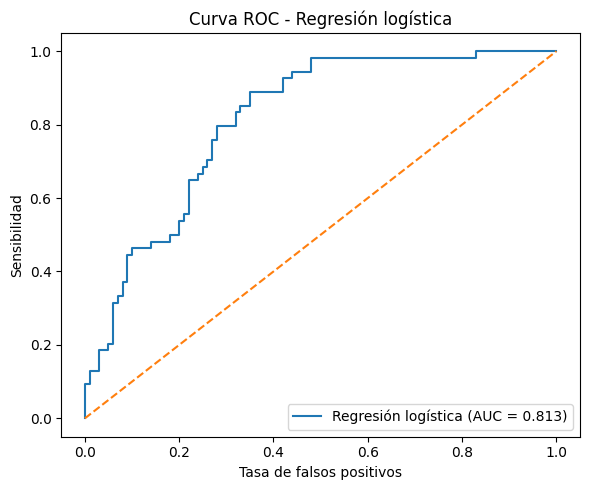

In [45]:
# Importar función para calcular la curva ROC
from sklearn.metrics import roc_curve

# Calcular los puntos de la curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob_logistic)

# Representar la curva ROC
plt.figure(figsize=(6, 5))

plt.plot(fpr, tpr, label=f"Regresión logística (AUC = {roc_auc:.3f})")

# Línea de referencia
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Sensibilidad")
plt.title("Curva ROC - Regresión logística")
plt.legend()
plt.tight_layout()
plt.show()

### 5.2 Árbol de decisión

Se entrenará un modelo de árbol de decisión empleando el mismo conjunto de entrenamiento y de prueba utilizado en la regresión logística, con el fin de comparar posteriormente el desempeño de ambos modelos.

In [46]:
# Importar el modelo de árbol de decisión
from sklearn.tree import DecisionTreeClassifier

# Crear el modelo
tree_model = DecisionTreeClassifier(random_state=42)

# Entrenar el modelo
tree_model.fit(X_train_scaled, y_train)

tree_model

DecisionTreeClassifier(random_state=42)

In [47]:
# Realizar predicciones sobre el conjunto de prueba
y_pred_tree = tree_model.predict(X_test_scaled)

# Visualizar las primeras predicciones
y_pred_tree[:10]

array([1, 0, 0, 1, 1, 0, 0, 1, 0, 1])

### 5.2.1 Evaluación del modelo

In [48]:
# Calcular probabilidades para la clase positiva
y_prob_tree = tree_model.predict_proba(X_test_scaled)[:, 1]

# Calcular métricas
accuracy_tree = accuracy_score(y_test, y_pred_tree)
precision_tree = precision_score(y_test, y_pred_tree)
sensitivity_tree = recall_score(y_test, y_pred_tree)
f1_tree = f1_score(y_test, y_pred_tree)
roc_auc_tree = roc_auc_score(y_test, y_prob_tree)

# Obtener valores de la matriz de confusión
tn_tree, fp_tree, fn_tree, tp_tree = confusion_matrix(y_test, y_pred_tree).ravel()

# Calcular especificidad
specificity_tree = tn_tree / (tn_tree + fp_tree)

# Mostrar resultados
print(f"Accuracy: {accuracy_tree:.3f}")
print(f"Precisión: {precision_tree:.3f}")
print(f"Sensibilidad (Recall): {sensitivity_tree:.3f}")
print(f"Especificidad: {specificity_tree:.3f}")
print(f"F1-score: {f1_tree:.3f}")
print(f"ROC-AUC: {roc_auc_tree:.3f}")

Accuracy: 0.682
Precisión: 0.553
Sensibilidad (Recall): 0.481
Especificidad: 0.790
F1-score: 0.515
ROC-AUC: 0.636


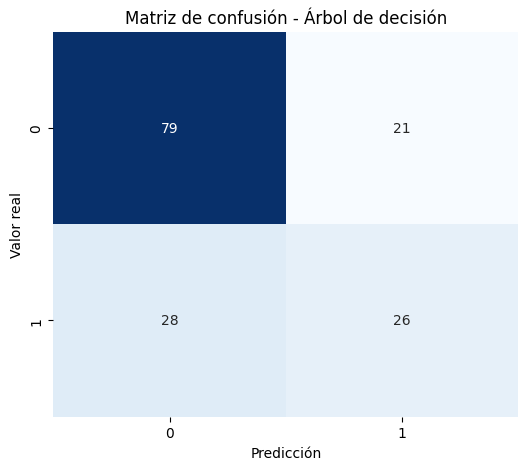

In [49]:
# Crear la matriz de confusión
cm_tree = confusion_matrix(y_test, y_pred_tree)

# Visualizar la matriz de confusión
plt.figure(figsize=(6, 5))

sns.heatmap(cm_tree, annot=True, fmt="d", cmap="Blues", cbar=False)

plt.title("Matriz de confusión - Árbol de decisión")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

### 5.2.2 Curva ROC

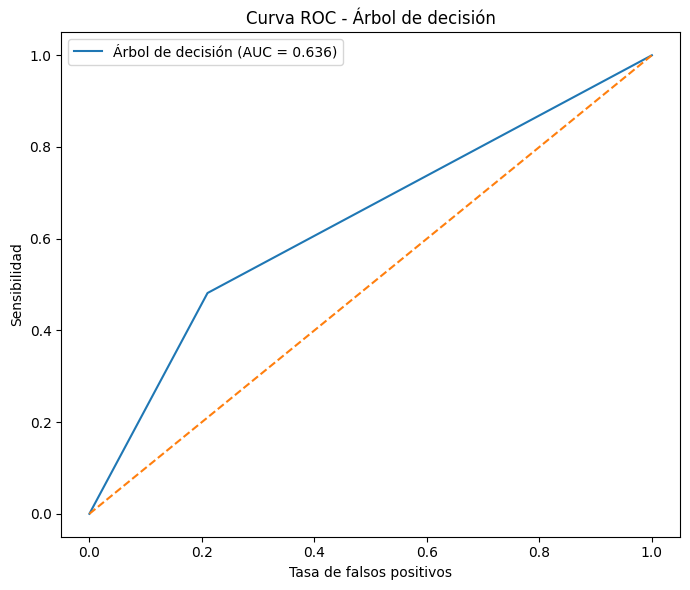

In [50]:
# Calcular la curva ROC
fpr_tree, tpr_tree, thresholds_tree = roc_curve(y_test, y_prob_tree)

# Graficar la curva ROC
plt.figure(figsize=(7, 6))

plt.plot(fpr_tree, tpr_tree,
         label=f"Árbol de decisión (AUC = {roc_auc_tree:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Sensibilidad")
plt.title("Curva ROC - Árbol de decisión")
plt.legend()
plt.tight_layout()
plt.show()

### 5.3 Random Forest

Se aplica un modelo de Random Forest como tercer algoritmo de clasificación.
Este enfoque integra varios árboles de decisión con el fin de potenciar el rendimiento predictivo y disminuir el riesgo de sobreajuste relacionado con un único árbol.

In [51]:
# Importar el modelo Random Forest
from sklearn.ensemble import RandomForestClassifier

# Crear el modelo
random_forest_model = RandomForestClassifier(random_state=42)

# Entrenar el modelo
random_forest_model.fit(X_train_scaled, y_train)

random_forest_model

RandomForestClassifier(random_state=42)

In [52]:
# Realizar predicciones sobre el conjunto de prueba
y_pred_rf = random_forest_model.predict(X_test_scaled)

# Visualizar las primeras predicciones
y_pred_rf[:10]

array([1, 0, 0, 0, 0, 0, 1, 1, 0, 1])

### 5.3.1 Evaluación del modelo

In [53]:
# Obtener probabilidades de la clase positiva
y_prob_rf = random_forest_model.predict_proba(X_test_scaled)[:, 1]

# Calcular métricas
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
sensitivity_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

# Obtener valores de la matriz de confusión
tn_rf, fp_rf, fn_rf, tp_rf = confusion_matrix(y_test, y_pred_rf).ravel()

# Calcular especificidad
specificity_rf = tn_rf / (tn_rf + fp_rf)

# Mostrar resultados
print(f"Accuracy: {accuracy_rf:.3f}")
print(f"Precision: {precision_rf:.3f}")
print(f"Sensitivity (Recall): {sensitivity_rf:.3f}")
print(f"Specificity: {specificity_rf:.3f}")
print(f"F1-score: {f1_rf:.3f}")
print(f"ROC-AUC: {roc_auc_rf:.3f}")

Accuracy: 0.773
Precision: 0.702
Sensitivity (Recall): 0.611
Specificity: 0.860
F1-score: 0.653
ROC-AUC: 0.818


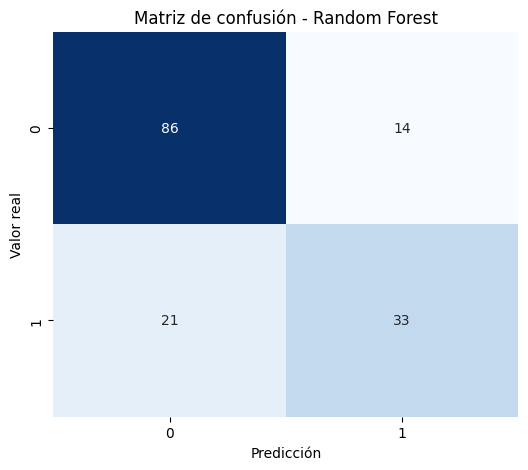

In [54]:
# Crear matriz de confusión
cm_rf = confusion_matrix(y_test, y_pred_rf)

# Visualizar matriz de confusión
plt.figure(figsize=(6, 5))

sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues", cbar=False)

plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title("Matriz de confusión - Random Forest")
plt.show()

### 5.3.2 Curva ROC

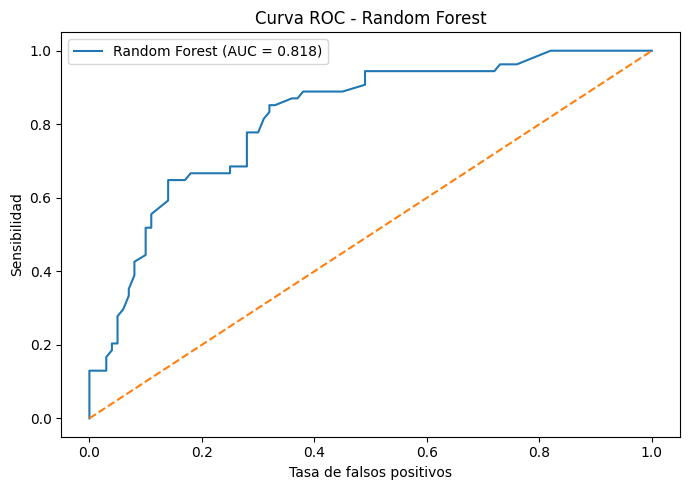

In [55]:
# Calcular los puntos de la curva ROC
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_prob_rf)

# Graficar curva ROC
plt.figure(figsize=(7, 5))

plt.plot(fpr_rf, tpr_rf,
         label=f"Random Forest (AUC = {roc_auc_rf:.3f})")

# Línea de referencia de un clasificador aleatorio
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Sensibilidad")
plt.title("Curva ROC - Random Forest")
plt.legend()
plt.tight_layout()
plt.show()

## 6. Comparación inicial de modelos

Después de entrenar los tres algoritmos de clasificación, se contrastan sus principales métricas de desempeño sobre el conjunto de prueba. Esta comparación facilita una evaluación preliminar para determinar qué modelo muestra un mejor comportamiento antes de llevar a cabo su validación y ajuste.

In [56]:
# Crear una tabla comparativa con las métricas de los tres modelos
model_comparison = pd.DataFrame({"Modelo": ["Regresión logística", "Árbol de decisión",
                                            "Random Forest"],
                                 "Accuracy": [accuracy, accuracy_tree, accuracy_rf],
                                 "Precision": [precision, precision_tree, precision_rf],
                                 "Sensibilidad": [sensitivity, sensitivity_tree, sensitivity_rf],
                                 "Especificidad": [specificity, specificity_tree, specificity_rf],
                                 "F1-score": [f1, f1_tree, f1_rf],
                                 "ROC-AUC": [roc_auc, roc_auc_tree, roc_auc_rf]})

# Mostrar los resultados redondeados a tres decimales
model_comparison.round(3)

,Modelo,Accuracy,Precision,Sensibilidad,Especificidad,F1-score,ROC-AUC
0,Regresión logística,0.708,0.600,0.500,0.82,0.545,0.813
1,Árbol de decisión,0.682,0.553,0.481,0.79,0.515,0.636
2,Random Forest,0.773,0.702,0.611,0.86,0.653,0.818


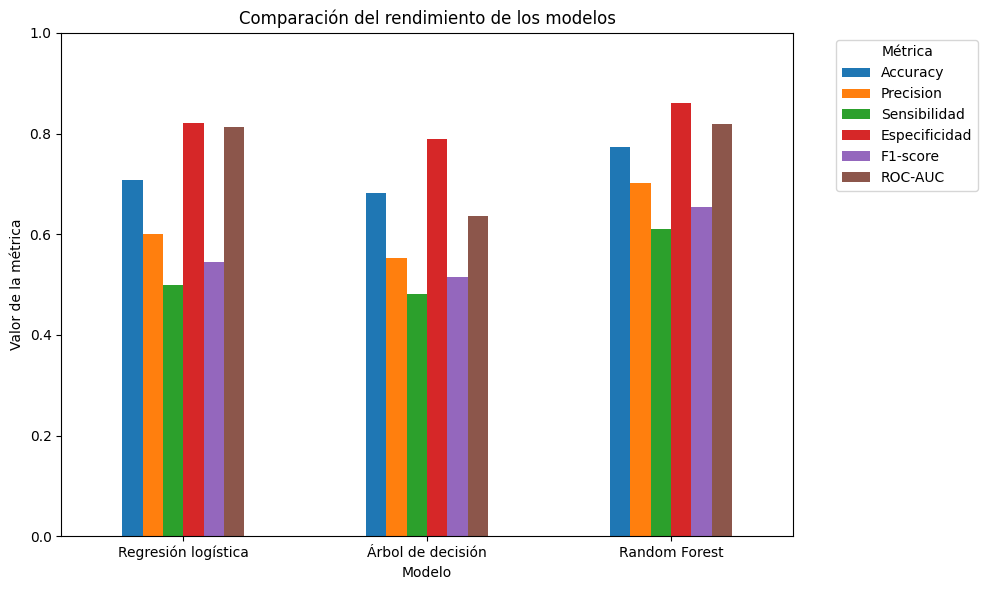

In [57]:
# Preparar los datos para la representación gráfica
comparison_plot = model_comparison.set_index("Modelo")

# Crear gráfico de barras
comparison_plot.plot(kind="bar", figsize=(10, 6))

plt.title("Comparación del rendimiento de los modelos")
plt.ylabel("Valor de la métrica")
plt.xlabel("Modelo")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Métrica", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 7. Configuración de la validación cruzada

Para valorar la estabilidad del desempeño de los modelos y disminuir la dependencia de una sola partición de entrenamiento y prueba, se estableció una estrategia de validación cruzada estratificada de cinco folds. La estratificación facilita conservar aproximadamente la proporción de las clases en cada partición.

In [58]:
# Importar herramientas para realizar la validación cruzada
from sklearn.model_selection import StratifiedKFold, cross_val_score

In [59]:
# Definir la validación cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

## 8. Validación cruzada mediante pipelines

Para prevenir la filtración de datos durante la validación cruzada, el preprocesamiento se incorporó junto con cada algoritmo mediante un pipeline. Así, la imputación de los valores faltantes y, si aplica, la estandarización de las variables se obtienen únicamente a partir de los datos de entrenamiento de cada fold.

In [60]:
# Importar Pipeline
from sklearn.pipeline import Pipeline

# Crear el pipeline de regresión logística
pipeline_logistic = Pipeline([("imputer", SimpleImputer(strategy="median")),("scaler", StandardScaler()),
 ("model", LogisticRegression(max_iter=1000, random_state=42))])

pipeline_logistic

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])

In [61]:
# Validación cruzada de la regresión logística mediante Pipeline
cv_scores_logistic_pipeline = cross_val_score(pipeline_logistic, X_train, y_train,
                                              cv=cv, scoring="roc_auc")

print("ROC-AUC por fold:")
print(cv_scores_logistic_pipeline)

print("\nROC-AUC medio:")
print(cv_scores_logistic_pipeline.mean().round(3))

print("\nDesviación estándar:")
print(cv_scores_logistic_pipeline.std().round(3))

ROC-AUC por fold:
[0.86686047 0.83953488 0.85116279 0.84854651 0.81071429]

ROC-AUC medio:
0.843

Desviación estándar:
0.019


In [62]:
# Crear el pipeline del Árbol de decisión
pipeline_tree = Pipeline([("imputer", SimpleImputer(strategy="median")),
 ("model", DecisionTreeClassifier(random_state=42))])

# Validación cruzada
cv_scores_tree_pipeline = cross_val_score(pipeline_tree, X_train, y_train,
                                          cv=cv, scoring="roc_auc")

print("ROC-AUC por fold:")
print(cv_scores_tree_pipeline)

print("\nROC-AUC medio:")
print(cv_scores_tree_pipeline.mean().round(3))

print("\nDesviación estándar:")
print(cv_scores_tree_pipeline.std().round(3))

ROC-AUC por fold:
[0.6818314  0.61744186 0.66206395 0.64607558 0.64761905]

ROC-AUC medio:
0.651

Desviación estándar:
0.021


In [63]:
# Crear el pipeline de Random Forest
pipeline_rf = Pipeline([("imputer", SimpleImputer(strategy="median")),
 ("model", RandomForestClassifier(random_state=42))])

# Validación cruzada
cv_scores_rf_pipeline = cross_val_score(pipeline_rf, X_train, y_train,
                                        cv=cv, scoring="roc_auc")

print("ROC-AUC por fold:")
print(cv_scores_rf_pipeline)

print("\nROC-AUC medio:")
print(cv_scores_rf_pipeline.mean().round(3))

print("\nDesviación estándar:")
print(cv_scores_rf_pipeline.std().round(3))

ROC-AUC por fold:
[0.82863372 0.81526163 0.85087209 0.79142442 0.7952381 ]

ROC-AUC medio:
0.816

Desviación estándar:
0.022


## 9. Ajuste de hiperparámetros

Con base en los resultados obtenidos mediante validación cruzada, se eligieron la regresión logística y Random Forest para llevar a cabo un ajuste de hiperparámetros, dado que ambos mostraron una capacidad discriminativa claramente mayor que la del árbol de decisión.

El ajuste se efectuó mediante GridSearchCV, empleando el área bajo la curva ROC como métrica de evaluación y manteniendo la misma estrategia de validación cruzada estratificada de cinco pliegues.

### 9.1 Optimización de Random Forest

In [64]:
# Importar GridSearchCV
from sklearn.model_selection import GridSearchCV

# Crear el pipeline de Random Forest
pipeline_rf_tuning = Pipeline([("imputer", SimpleImputer(strategy="median")),
 ("model", RandomForestClassifier(random_state=42))])

# Definir los hiperparámetros que se evaluarán
param_grid_rf = {"model__n_estimators": [100, 200], "model__max_depth": [None, 5, 10],
                 "model__min_samples_split": [2, 5], "model__min_samples_leaf": [1, 2]}

# Realizar la búsqueda de hiperparámetros
grid_search_rf = GridSearchCV(estimator=pipeline_rf_tuning, param_grid=param_grid_rf,
                              cv=cv, scoring="roc_auc", n_jobs=-1)

# Entrenar
grid_search_rf.fit(X_train, y_train)

# Mostrar resultados
print("Mejores hiperparámetros:")
print(grid_search_rf.best_params_)

print("\nMejor ROC-AUC medio:")
print(round(grid_search_rf.best_score_, 3))

Mejores hiperparámetros:
{'model__max_depth': 5, 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 100}

Mejor ROC-AUC medio:
0.839


### 9.2 Optimización de la Regresión Logística

In [65]:
# Crear el pipeline para ajustar la regresión logística
pipeline_logistic_tuning = Pipeline([("imputer", SimpleImputer(strategy="median")),
 ("scaler", StandardScaler()), ("model", LogisticRegression(max_iter=1000, random_state=42))])

# Hiperparámetros que se evaluarán
param_grid_logistic = {"model__C": [0.01, 0.1, 1, 10, 100]}

# Búsqueda de hiperparámetros
grid_search_logistic = GridSearchCV(estimator=pipeline_logistic_tuning, param_grid=param_grid_logistic,
                                    cv=cv, scoring="roc_auc", n_jobs=-1)

# Entrenar
grid_search_logistic.fit(X_train, y_train)

# Mostrar resultados
print("Mejores hiperparámetros:")
print(grid_search_logistic.best_params_)

print("\nMejor ROC-AUC medio:")
print(round(grid_search_logistic.best_score_, 3))

Mejores hiperparámetros:
{'model__C': 0.1}

Mejor ROC-AUC medio:
0.844


## 10. Evaluación final de los modelos optimizados

In [66]:
# Recuperar los mejores modelos obtenidos durante el ajuste
best_logistic_model = grid_search_logistic.best_estimator_
best_rf_model = grid_search_rf.best_estimator_

In [67]:
# Función para evaluar un modelo
def evaluar_modelo(modelo, X_test, y_test):

    # Realizar predicciones
    y_pred = modelo.predict(X_test)

    # Obtener probabilidades para la clase positiva
    y_prob = modelo.predict_proba(X_test)[:, 1]

    # Calcular matriz de confusión
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    # Calcular métricas
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    sensibilidad = recall_score(y_test, y_pred)
    especificidad = tn / (tn + fp)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    return {"Accuracy": accuracy, "Precisión": precision, "Sensibilidad": sensibilidad,
            "Especificidad": especificidad, "F1-score": f1, "ROC-AUC": roc_auc}

In [68]:
# Evaluar los modelos optimizados
resultados_logistic_final = evaluar_modelo(best_logistic_model,
                                           X_test, y_test)

resultados_rf_final = evaluar_modelo(best_rf_model, X_test,
                                     y_test)

In [69]:
# Crear tabla comparativa de los modelos optimizados
comparacion_final = pd.DataFrame([resultados_logistic_final, resultados_rf_final],
                                 index=["Regresión logística", "Random Forest"])

# Mostrar resultados redondeados a tres decimales
comparacion_final.round(3)

,Accuracy,Precisión,Sensibilidad,Especificidad,F1-score,ROC-AUC
Regresión logística,0.688,0.565,0.481,0.80,0.520,0.810
Random Forest,0.747,0.683,0.519,0.87,0.589,0.818


## 11. Matrices de confusión de los modelos optimizados

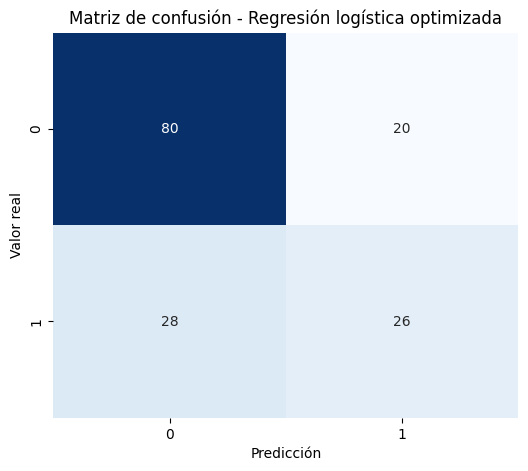

In [70]:
# Predicciones de los modelos optimizados
y_pred_logistic_final = best_logistic_model.predict(X_test)
y_pred_rf_final = best_rf_model.predict(X_test)

# Matrices de confusión
cm_logistic_final = confusion_matrix(y_test, y_pred_logistic_final)
cm_rf_final = confusion_matrix(y_test, y_pred_rf_final)

# Matriz de confusión - Regresión logística
plt.figure(figsize=(6, 5))

sns.heatmap(cm_logistic_final, annot=True, fmt="d", cmap="Blues",
            cbar=False)

plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title("Matriz de confusión - Regresión logística optimizada")
plt.show()

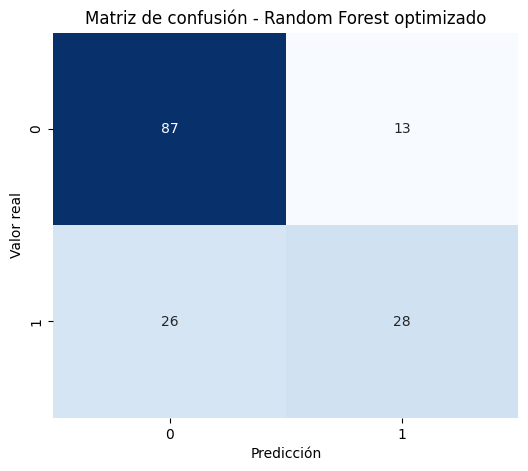

In [71]:
# Matriz de confusión - Random Forest
plt.figure(figsize=(6, 5))

sns.heatmap(cm_rf_final, annot=True, fmt="d", cmap="Blues",
            cbar=False)

plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title("Matriz de confusión - Random Forest optimizado")
plt.show()

## 12. Comparación de las curvas ROC de los modelos optimizados

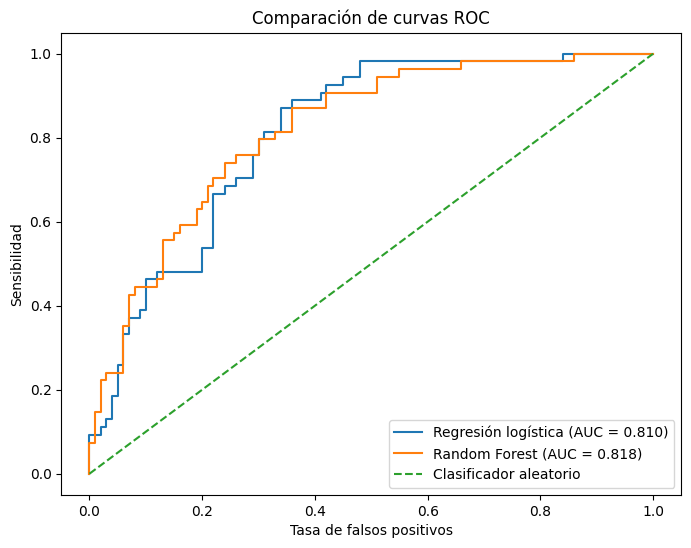

In [72]:
# Obtener probabilidades de la clase positiva
y_prob_logistic_final = best_logistic_model.predict_proba(X_test)[:, 1]
y_prob_rf_final = best_rf_model.predict_proba(X_test)[:, 1]

# Calcular las curvas ROC
fpr_logistic, tpr_logistic, _ = roc_curve(y_test, y_prob_logistic_final)

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf_final)

# Calcular ROC-AUC
auc_logistic_final = roc_auc_score(y_test, y_prob_logistic_final)

auc_rf_final = roc_auc_score(y_test, y_prob_rf_final)

# Graficar ambas curvas
plt.figure(figsize=(8, 6))

plt.plot(fpr_logistic, tpr_logistic,
         label=f"Regresión logística (AUC = {auc_logistic_final:.3f})")

plt.plot(fpr_rf, tpr_rf,
         label=f"Random Forest (AUC = {auc_rf_final:.3f})")

# Línea de referencia
plt.plot([0, 1], [0, 1], linestyle="--",
         label="Clasificador aleatorio")

plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Sensibilidad")
plt.title("Comparación de curvas ROC")
plt.legend()
plt.show()

## 13. Selección del modelo final

Tras la optimización de hiperparámetros, ambos modelos evidenciaron una capacidad discriminativa comparable cuando se evaluaron con el conjunto de prueba. La regresión logística obtuvo un ROC-AUC de 0.810, mientras que Random Forest alcanzó un ROC-AUC de 0.818.

Además del ROC-AUC, Random Forest mostró resultados superiores en accuracy (0.747 frente a 0.688), precisión (0.683 frente a 0.565), sensibilidad (0.519 frente a 0.481), especificidad (0.870 frente a 0.800) y F1-score (0.589 frente a 0.520).

La matriz de confusión también puso de manifiesto que Random Forest identificó correctamente un mayor número de casos positivos y generó menos falsos positivos que la regresión logística.

Por estas razones, se eligió Random Forest como modelo final. Sin embargo, la sensibilidad observada sugiere que el modelo aún presenta limitaciones para detectar todos los casos positivos, de modo que sus resultados deben interpretarse con cautela.

## 14. Interpretación del modelo final

Tras elegir Random Forest como modelo final, se examina la importancia de las variables con el fin de determinar qué características aportan una contribución mayor a las predicciones generadas por el modelo.

In [73]:
# Obtener el mejor modelo Random Forest obtenido mediante GridSearchCV
best_rf_pipeline = grid_search_rf.best_estimator_

# Extraer el modelo Random Forest del Pipeline
best_rf_model = best_rf_pipeline.named_steps["model"]

# Obtener la importancia de cada variable
feature_importances = best_rf_model.feature_importances_

# Crear una tabla con las variables y sus importancias
importance_df = pd.DataFrame({"Variable": X.columns,
                              "Importancia": feature_importances})

# Ordenar las variables de mayor a menor importancia
importance_df = importance_df.sort_values(by="Importancia",
                                          ascending=False).reset_index(drop=True)

# Mostrar resultados
importance_df.round(3)

,Variable,Importancia
0,Glucose,0.385
1,BMI,0.170
2,Age,0.115
3,Insulin,0.095
4,DiabetesPedigreeFunction,0.083
5,Pregnancies,0.058
6,SkinThickness,0.051
7,BloodPressure,0.043


### 14.1 Importancia de las variables

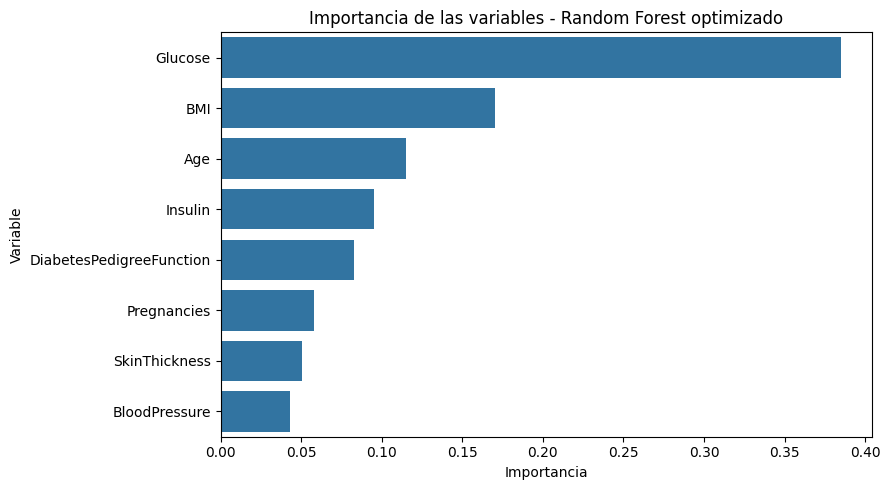

In [74]:
# Visualizar la importancia de las variables del modelo final
plt.figure(figsize=(9, 5))

sns.barplot(data=importance_df, x="Importancia", y="Variable")

plt.title("Importancia de las variables - Random Forest optimizado")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

El análisis de la importancia de las variables del modelo de Random Forest indicó que la concentración de glucosa fue la característica que más contribuyó a las predicciones del modelo, con una importancia de 0.385. A continuación se ubicaron el índice de masa corporal (BMI), con 0.170, y la edad, con 0.115.

En un segundo nivel de contribución, se observaron la concentración de insulina (0.095) y la función de pedigrí de la diabetes, con 0.083. Las variables con menor importancia relativa fueron el número de embarazos (0.058), el grosor de la piel (0.051) y la presión arterial (0.043).

Estos hallazgos permiten señalar las variables que aportaron una mayor contribución a las decisiones del modelo. No obstante, que una variable presente importancia dentro del Random Forest no significa necesariamente que exista una relación causal con el desarrollo de diabetes.

### 14.2 Curva Precisión-Recall del modelo final

Como análisis complementario, se examina la relación entre la precisión y la sensibilidad a través de la curva precisión-recall. Esta visualización facilita evaluar el desempeño del modelo para identificar la clase positiva en distintos umbrales de clasificación.

In [75]:
# Importar funciones necesarias
from sklearn.metrics import precision_recall_curve, average_precision_score

# Obtener probabilidades de pertenecer a la clase positiva
y_prob_rf_final = best_rf_pipeline.predict_proba(X_test)[:, 1]

# Calcular Precision-Recall para diferentes umbrales
precision_curve, recall_curve, thresholds = precision_recall_curve(y_test,
                                                                   y_prob_rf_final)

# Calcular Average Precision
average_precision = average_precision_score(y_test, y_prob_rf_final)

print("Average Precision:", round(average_precision, 3))

Average Precision: 0.698


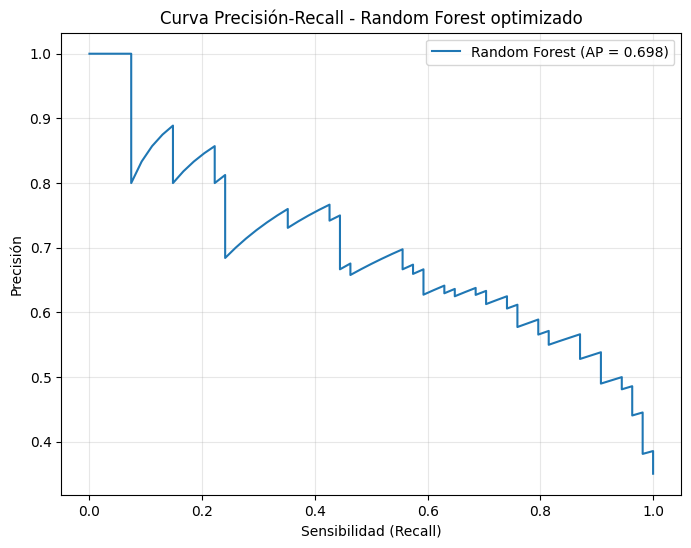

In [76]:
# Graficar la curva Precision-Recall
plt.figure(figsize=(8, 6))

plt.plot(recall_curve, precision_curve, label=f"Random Forest (AP = {average_precision:.3f})")

plt.xlabel("Sensibilidad (Recall)")
plt.ylabel("Precisión")
plt.title("Curva Precisión-Recall - Random Forest optimizado")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 15. Análisis del umbral de clasificación

El modelo, de forma predeterminada, asigna las clases a los pacientes mediante un umbral de probabilidad de 0.50. No obstante, en un problema de clasificación vinculado con la diabetes, es pertinente examinar el impacto de alterar dicho umbral sobre la sensibilidad y la especificidad del modelo.

Se analizarán distintos puntos de corte con el fin de estudiar el equilibrio entre la identificación de pacientes positivos y la producción de falsos positivos.

In [77]:
# Obtener el mejor modelo Random Forest encontrado por GridSearchCV
best_rf = grid_search_rf.best_estimator_

# Comprobar el modelo seleccionado
best_rf

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('model',
                 RandomForestClassifier(max_depth=5, min_samples_leaf=2,
                                        min_samples_split=5,
                                        random_state=42))])

In [78]:
# Probabilidades predichas por el Random Forest optimizado
y_prob_rf_opt = best_rf.predict_proba(X_test)[:, 1]

# Umbrales que vamos a evaluar
thresholds = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]

resultados_umbral = []

for threshold in thresholds:

    # Convertir probabilidades en predicciones según el umbral
    y_pred_threshold = (y_prob_rf_opt >= threshold).astype(int)

    # Matriz de confusión
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_threshold).ravel()

    # Calcular métricas
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    precision = precision_score(y_test, y_pred_threshold)
    f1 = f1_score(y_test, y_pred_threshold)

    # Guardar resultados
    resultados_umbral.append({
        "Umbral": threshold,
        "Sensibilidad": sensitivity,
        "Especificidad": specificity,
        "Precisión": precision,
        "F1-score": f1
    })

# Crear tabla
threshold_results = pd.DataFrame(resultados_umbral)

threshold_results.round(3)

,Umbral,Sensibilidad,Especificidad,Precisión,F1-score
0,0.30,0.815,0.66,0.564,0.667
1,0.35,0.778,0.70,0.583,0.667
2,0.40,0.741,0.75,0.615,0.672
3,0.45,0.593,0.81,0.627,0.610
4,0.50,0.519,0.87,0.683,0.589
5,0.55,0.463,0.87,0.658,0.543
6,0.60,0.426,0.93,0.767,0.548


### 15.1 Comparación del umbral estándar y el umbral ajustado

Se evaluó el desempeño del modelo Random Forest optimizado mediante el uso de un umbral estándar de 0.50 y un umbral alternativo de 0.40, con el fin de examinar cómo el punto de corte influye en la sensibilidad, la especificidad, la precisión y el F1-score.

In [79]:
# Crear predicciones con umbral 0.50
y_pred_050 = (y_prob_rf_opt >= 0.50).astype(int)

# Crear predicciones con umbral 0.40
y_pred_040 = (y_prob_rf_opt >= 0.40).astype(int)

def metricas_umbral(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    return {"Sensibilidad": tp / (tp + fn), "Especificidad": tn / (tn + fp),
            "Precisión": precision_score(y_true, y_pred), "F1-score": f1_score(y_true, y_pred),
            "Falsos negativos": fn, "Falsos positivos": fp}

resultados_050 = metricas_umbral(y_test, y_pred_050)
resultados_040 = metricas_umbral(y_test, y_pred_040)

comparacion_umbrales = pd.DataFrame([resultados_050, resultados_040], index=["Umbral 0.50", "Umbral 0.40"])

comparacion_umbrales.round(3)

,Sensibilidad,Especificidad,Precisión,F1-score,Falsos negativos,Falsos positivos
Umbral 0.50,0.519,0.87,0.683,0.589,26,13
Umbral 0.40,0.741,0.75,0.615,0.672,14,25


### 15.2 Matriz de confusión con umbral ajustado

Tras analizar distintos puntos de corte, se examinó el desempeño del Random Forest optimizado empleando un umbral de clasificación de 0.40. Esta modificación pretende incrementar la capacidad de identificar los casos positivos, disminuyendo el número de falsos negativos.

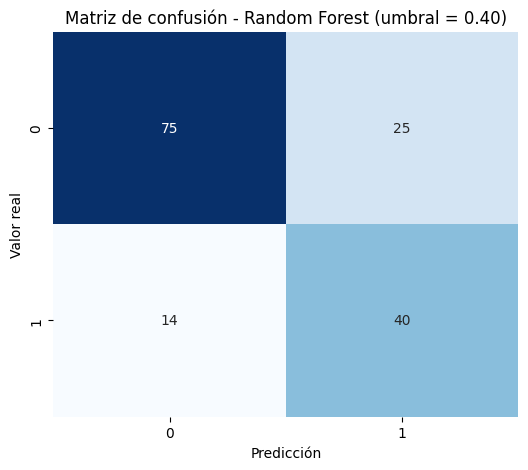

In [80]:
# Matriz de confusión con umbral 0.40
cm_rf_040 = confusion_matrix(y_test, y_pred_040)

# Visualizar matriz de confusión
plt.figure(figsize=(6, 5))

sns.heatmap(cm_rf_040, annot=True, fmt="d", cmap="Blues",
            cbar=False)

plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title("Matriz de confusión - Random Forest (umbral = 0.40)")

plt.show()

### 15.3 Selección del umbral mediante el índice de Youden

Como complemento del análisis de los puntos de corte, se obtuvo el índice de Youden a partir de la curva ROC. Dicho índice permite determinar el umbral que optimiza de manera conjunta la sensibilidad y la especificidad del modelo.

In [81]:
# Calcular curva ROC del Random Forest optimizado
fpr, tpr, thresholds_roc = roc_curve(y_test, y_prob_rf_opt)

# Calcular índice de Youden
youden_index = tpr - fpr

# Encontrar la posición del valor máximo
best_index = np.argmax(youden_index)

# Obtener el umbral correspondiente
best_threshold = thresholds_roc[best_index]

print("Umbral según índice de Youden:",
      round(best_threshold, 3))

print("Sensibilidad:",
      round(tpr[best_index], 3))

print("Especificidad:",
      round(1 - fpr[best_index], 3))

print("Índice de Youden:",
      round(youden_index[best_index], 3))

Umbral según índice de Youden: 0.26
Sensibilidad: 0.87
Especificidad: 0.64
Índice de Youden: 0.51


In [82]:
# Umbrales candidatos
thresholds_final = [0.50, 0.40, best_threshold]

resultados_finales_umbral = []

for threshold in thresholds_final:

    # Generar predicciones
    y_pred_temp = (y_prob_rf_opt >= threshold).astype(int)

    # Matriz de confusión
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_temp).ravel()

    # Guardar métricas
    resultados_finales_umbral.append({"Umbral": threshold, "Sensibilidad": recall_score(y_test, y_pred_temp),
                                      "Especificidad": tn / (tn + fp),
                                      "Precisión": precision_score(y_test, y_pred_temp),
                                      "F1-score": f1_score(y_test, y_pred_temp),
                                      "Verdaderos positivos": tp,
                                      "Falsos negativos": fn,
                                      "Falsos positivos": fp,
                                      "Verdaderos negativos": tn})

comparacion_thresholds_final = pd.DataFrame(resultados_finales_umbral)

comparacion_thresholds_final.round(3)

,Umbral,Sensibilidad,Especificidad,Precisión,F1-score,Verdaderos positivos,Falsos negativos,Falsos positivos,Verdaderos negativos
0,0.50,0.519,0.87,0.683,0.589,28,26,13,87
1,0.40,0.741,0.75,0.615,0.672,40,14,25,75
2,0.26,0.870,0.64,0.566,0.686,47,7,36,64


### 15.4 Comparación de los umbrales candidatos

Se contrastaron el umbral convencional de 0.50, el umbral de 0.40 determinado durante el análisis exploratorio de puntos de corte y el umbral derivado del índice de Youden, con el propósito de valorar el equilibrio entre sensibilidad, especificidad y los errores de clasificación.

### 15.5 Selección del umbral de clasificación

El umbral convencional de 0.50 arrojó una sensibilidad de 0.519, acompañada de 26 falsos negativos. Cuando el umbral se ajustó a 0.40, la sensibilidad se incrementó hasta 0.741 y los falsos negativos se redujeron a 14, conservando una especificidad de 0.750.

El índice de Youden señaló un umbral de 0.26, con una sensibilidad de 0.870 y una especificidad de 0.640. Aunque este punto de corte permitió disminuir los falsos negativos a 7, también elevó los falsos positivos a 36.

Al tomar en cuenta el equilibrio entre sensibilidad, especificidad, el F1-score y los errores de clasificación, se eligió un umbral de 0.40 como punto de corte operativo para el modelo. Si bien el índice de Youden determinó un umbral de 0.26 como el valor que maximiza de manera conjunta la sensibilidad y la especificidad, dicho umbral generó una mayor cantidad de falsos positivos. En contraste, el umbral de 0.40 incrementó de forma notable la detección de casos positivos frente al umbral convencional de 0.50, al pasar los falsos negativos de 26 a 14, sin llegar al aumento de falsos positivos observado con el umbral de 0.26.

## 16. Evaluación final del modelo seleccionado

Tras la comparación de los modelos, la optimización de hiperparámetros y el análisis de distintos umbrales de clasificación, se eligió el modelo Random Forest optimizado, con un umbral de decisión de 0.40.

A continuación, se valora su desempeño final en el conjunto de prueba mediante las principales métricas de clasificación.

In [83]:
# Umbral seleccionado
umbral_final = 0.40

# Convertir las probabilidades en predicciones utilizando el umbral seleccionado
y_pred_final = (y_prob_rf_opt >= umbral_final).astype(int)

# Obtener la matriz de confusión
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_final).ravel()

# Calcular las métricas finales
accuracy_final = accuracy_score(y_test, y_pred_final)
precision_final = precision_score(y_test, y_pred_final)
sensitivity_final = recall_score(y_test, y_pred_final)
specificity_final = tn / (tn + fp)
f1_final = f1_score(y_test, y_pred_final)

# El ROC-AUC se calcula utilizando probabilidades
roc_auc_final = roc_auc_score(y_test, y_prob_rf_opt)

# Crear tabla con los resultados finales
resultados_finales = pd.DataFrame({"Métrica": ["Accuracy", "Precisión", "Sensibilidad",
                                               "Especificidad", "F1-score", "ROC-AUC"],
                                   "Valor": [accuracy_final, precision_final, sensitivity_final,
                                             specificity_final, f1_final, roc_auc_final]})

resultados_finales.round(3)

,Métrica,Valor
0,Accuracy,0.747
1,Precisión,0.615
2,Sensibilidad,0.741
3,Especificidad,0.750
4,F1-score,0.672
5,ROC-AUC,0.818


### 16.1 Interpretación del rendimiento final

El modelo Random Forest optimizado, al emplear un umbral de clasificación de 0.40, alcanzó un accuracy de 0.747, lo que sugiere que acertó aproximadamente en el 74.7% de las observaciones del conjunto de prueba.

La sensibilidad, con un valor de 0.741, muestra que el modelo identificó correctamente cerca del 74.1% de los pacientes que pertenecen a la clase positiva. En paralelo, la especificidad fue de 0.750, lo que indica que reconoció adecuadamente el 75.0% de los pacientes correspondientes a la clase negativa.

La precisión tomó un valor de 0.615, es decir, aproximadamente el 61.5% de los pacientes que el modelo clasificó como positivos efectivamente pertenecían a dicha clase. El F1-score fue de 0.672, reflejando el balance entre precisión y sensibilidad.

Finalmente, el ROC-AUC alcanzó 0.818, lo cual evidencia una buena capacidad del modelo para discriminar entre las clases positiva y negativa. Cabe destacar que esta métrica se obtiene a partir de las probabilidades predichas y, por consiguiente, no depende del umbral de clasificación seleccionado.

El uso de un umbral de 0.40 permitió elevar la sensibilidad frente al umbral convencional de 0.50, disminuyendo los falsos negativos de 26 a 14. Como contrapartida, los falsos positivos aumentaron de 13 a 25 y la especificidad se redujo. Este patrón ilustra el compromiso existente entre detectar un mayor número de casos positivos y el incremento de clasificaciones positivas incorrectas. En el marco de la detección de diabetes, incrementar la sensibilidad puede resultar especialmente relevante cuando se pretende reducir la cantidad de casos positivos no identificados; no obstante, la determinación final del punto de corte para una aplicación clínica exigiría tener en cuenta también las implicaciones y los costes asociados a ambos tipos de error.

## 17. Conclusiones del análisis

En este análisis se desarrollaron y evaluaron tres algoritmos de clasificación: regresión logística, árbol de decisión y Random Forest, con el fin de predecir la pertenencia de los pacientes a las clases positiva y negativa.

La comparación inicial evidenció un rendimiento mayor del Random Forest frente al árbol de decisión, mientras que la regresión logística también mostró una capacidad discriminativa satisfactoria. Posteriormente, la validación cruzada y la optimización de hiperparámetros permitieron analizar con mayor robustez el comportamiento de los modelos y elegir el Random Forest optimizado como modelo final.

El Random Forest optimizado obtuvo un valor de ROC-AUC de 0.818 en el conjunto de prueba. Empleando el umbral convencional de 0.50, el modelo registró una sensibilidad de 0.519 y una especificidad de 0.870. Dado que una sensibilidad más alta contribuye a disminuir el número de casos positivos no identificados, se examinó el impacto de distintos puntos de corte sobre el desempeño del modelo.

Finalmente, se adoptó un umbral de 0.40; con él, el modelo alcanzó un accuracy de 0.747, una precisión de 0.615, una sensibilidad de 0.741, una especificidad de 0.750 y un F1-score de 0.672. Con este umbral, los falsos negativos se redujeron de 26 a 14 frente al umbral convencional de 0.50, aunque ello estuvo acompañado por un aumento de los falsos positivos.

El análisis de importancia de variables indicó que la glucosa presentó la mayor contribución relativa a las predicciones del modelo, seguida del índice de masa corporal (BMI), la edad, la insulina y la función de pedigrí de la diabetes.

En conjunto, los resultados sugieren que el Random Forest muestra una capacidad discriminativa adecuada en este conjunto de datos y que modificar el umbral de clasificación permite ajustar el equilibrio entre sensibilidad y especificidad. No obstante, el desempeño debe interpretarse a la luz de las características y limitaciones del conjunto analizado; por tanto, estos resultados por sí solos no constituyen una validación para su uso como herramienta diagnóstica en la práctica clínica.

### 17.1 Limitaciones

Los resultados obtenidos deben interpretarse teniendo en cuenta diversas limitaciones. En primer lugar, el tamaño y las características del conjunto de datos pueden restringir la capacidad de generalización del modelo hacia otras poblaciones.

Además, algunas variables presentaban valores ausentes o requirieron algún tratamiento durante el preprocesamiento, de modo que las decisiones tomadas para su imputación podrían afectar el rendimiento de los modelos.

Aunque, durante el desarrollo de los modelos, se emplearon técnicas de validación cruzada y un conjunto de prueba independiente, antes de contemplar una posible aplicación clínica sería necesario llevar a cabo una validación externa con datos procedentes de otras poblaciones o instituciones.

Asimismo, la relevancia de las variables obtenida mediante Random Forest refleja su contribución relativa a las predicciones del modelo y no implica necesariamente la existencia de una relación causal con la diabetes.

Otra limitación se relaciona con la elección del umbral de clasificación. El umbral de 0.40 se seleccionó tras examinar distintos puntos de corte sobre el mismo conjunto de prueba utilizado, posteriormente, para reportar el rendimiento final del modelo. Por esta razón, las métricas obtenidas con dicho umbral deben considerarse una estimación exploratoria del desempeño, y sería necesario confirmar el punto de corte seleccionado en un conjunto de datos independiente.

Finalmente, la selección de un umbral para una posible aplicación clínica no debería fundamentarse únicamente en el equilibrio entre sensibilidad y especificidad. También sería preciso evaluar las implicaciones clínicas y los costes asociados a los falsos positivos y falsos negativos, además del contexto específico en el que se pretendiera utilizar el modelo.

## 18. Simulación de uso en nuevos pacientes

In [84]:
# Variables predictoras utilizadas por el modelo
variables = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness", "Insulin",
             "BMI", "DiabetesPedigreeFunction", "Age"]

# 1. Calcular percentiles para construir los perfiles

# Percentiles generales del conjunto de datos
percentiles = df[variables].quantile([0.25, 0.50, 0.75])

# Para SkinThickness e Insulin se excluyen los valores iguales a 0,
# ya que no representan mediciones fisiológicas válidas
skin_percentiles = (df.loc[df["SkinThickness"] > 0, "SkinThickness"].quantile([0.25, 0.50, 0.75]))

insulin_percentiles = (df.loc[df["Insulin"] > 0, "Insulin"].quantile([0.25, 0.50, 0.75]))

# Sustituir los percentiles originales por los calculados únicamente a partir de valores mayores que 0
percentiles.loc[:, "SkinThickness"] = skin_percentiles.values
percentiles.loc[:, "Insulin"] = insulin_percentiles.values

# 2. Crear los tres perfiles simulados

pacientes_simulados = pd.DataFrame([percentiles.loc[0.25], percentiles.loc[0.50], percentiles.loc[0.75]],
                                   index=["Perfil 1", "Perfil 2", "Perfil 3"])

print("Perfiles simulados:")
display(pacientes_simulados.round(3))

# 3. Obtener la probabilidad estimada por el Random Forest

probabilidades_simuladas = best_rf.predict_proba(pacientes_simulados)[:, 1]

# 4. Aplicar el umbral de clasificación seleccionado

umbral_final = 0.40

predicciones_simuladas = (probabilidades_simuladas >= umbral_final).astype(int)

# 5. Crear la tabla final de resultados

resultados_simulacion = pacientes_simulados.copy()

resultados_simulacion["Probabilidad estimada"] = (probabilidades_simuladas)

resultados_simulacion["Clasificación"] = (predicciones_simuladas)

print("\nResultados de la simulación:")
display(resultados_simulacion.round(3))

Perfiles simulados:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Perfil 1,1.0,99.00,62.0,22.0,76.25,27.3,0.244,24.0
Perfil 2,3.0,117.00,72.0,29.0,125.00,32.0,0.372,29.0
Perfil 3,6.0,140.25,80.0,36.0,190.00,36.6,0.626,41.0



Resultados de la simulación:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Probabilidad estimada,Clasificación
Perfil 1,1.0,99.00,62.0,22.0,76.25,27.3,0.244,24.0,0.029,0
Perfil 2,3.0,117.00,72.0,29.0,125.00,32.0,0.372,29.0,0.331,0
Perfil 3,6.0,140.25,80.0,36.0,190.00,36.6,0.626,41.0,0.646,1
